Title: PSL_mean_and_anomaly_new.ipynb

Purpose: Calculate a model mean and the psl anomaly data

Author: Onno Nennecke on 02.06.2025 Modified: 23.03.2026

Input data: 

- PSL Data from ERA5 and CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
- Used Runs File: CESM2_LE_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- PSL winter means Data: psl_mean_combined.nc
    - This file lies here: /climca/people/onennecke/model_output/var_means/psl_not_bc/
- PSL Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/psl_anomaly/not_bc/

### Load libraries and functions

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

### Read data

In [3]:
# Read the dataframe from the csv file
used_runs_CMIP = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')

used_runs_CESM = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')

used_runs = pd.concat([used_runs_CMIP, used_runs_CESM], ignore_index=True)

# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)
used_runs

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [4]:
used_runs

,ESM,Institution,run
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1
3,BCC-CSM2-MR,BCC,r1i1p1f1
4,CESM2,NCAR,r4i1p1f1
...,...,...,...
188,CESM2,NCAR,LE2-1301_017
189,CESM2,NCAR,LE2-1301_018
190,CESM2,NCAR,LE2-1301_019
191,CESM2,NCAR,LE2-1301_020


In [5]:
base_path = '/climca/people/onennecke/not_debiased_data/'
psl_files = []
for i in range(len(used_runs)):
    ESM = used_runs.loc[i, 'ESM']
    run = used_runs.loc[i, 'run']
    
    # Construct the file path
    file_path = os.path.join(base_path, f'{ESM}_{run}_psl.nc')
    # Check if the file exists    
    if not os.path.isfile(file_path):
        print(f'File not found: {file_path}')
    else:
        psl_files.append(file_path)
print(len(psl_files))
# psl_files 
psl_ds = xr.open_dataset(psl_files[20])  # Open the first file to check the structure
psl_ds.load()

# Open the files using xarray
# psl_ds = xr.open_mfdataset(psl_files, combine='by_coords')



193


<xarray.Dataset> Size: 29MB
Dimensions:   (time: 3650, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U8 32B 'r5i1p1f1'
    ESM_run   <U18 72B 'EC-Earth3_r5i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 29MB 1.017e+05 1.018e+05 ... 1.012e+05
Attributes:
    regrid_method:  bilinear

In [15]:
out_dir = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in psl_files if esm in os.path.basename(fn)]
    output_file = f'{esm}_psl_mean_and_anomaly.nc'
    if os.path.isfile(os.path.join(out_dir, output_file)):
        print(f'{output_file} already exists. Skipping {esm}.')
        continue
    
    print(f'Processing {esm} with {len(esm_files)} files...')
    ds = xr.open_mfdataset(esm_files, combine='nested', concat_dim='ESM_run')
    ds_fixed = ds.convert_calendar('noleap', align_on='year')
    ds_mean = ds_fixed.mean('ESM_run')
    
    
    clim = ds_mean.groupby('time.dayofyear').mean('time')
    
    clim_pad = xr.concat([clim.isel(dayofyear=slice(-7, None)),
                          clim,
                          clim.isel(dayofyear=slice(0, 7))],
                         dim='dayofyear')
    clim_smooth = (
        clim_pad
        .rolling(dayofyear=15, center=True)
        .mean()
        .isel(dayofyear=slice(7, 7+365))
    )
    
    anom = ds_fixed.groupby('time.dayofyear') - clim_smooth

    anom = anom.sel(time=anom['time.month'].isin([10,11,12,1,2,3]))
    
    encoding = {}

    all_vars = {**anom.data_vars, **anom.coords}

    for var, da in all_vars.items():
        if da.dtype.kind in {"U", "S"}:
            values = da.values.astype(str)
            if values.ndim == 0:
                maxlen = len(str(values))
            else:
                maxlen = max(map(len, values.flatten()))
            encoding[var] = {"dtype": f"U{maxlen}"}
    encoding
    
    anom.to_netcdf(os.path.join(out_dir, output_file), encoding=encoding)
    
    # break

Processing ACCESS-CM2 with 3 files...
Processing BCC-CSM2-MR with 1 files...
Processing CESM2 with 103 files...


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/array/core.py:5092: PerformanceWarning: Increasing number of chunks by factor of 103
  result = blockwise(


Processing EC-Earth3 with 54 files...


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/array/core.py:5092: PerformanceWarning: Increasing number of chunks by factor of 54
  result = blockwise(


Processing GFDL-ESM4 with 1 files...
Processing KACE-1-0-G with 3 files...
Processing MPI-ESM1-2-HR with 10 files...


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/array/core.py:5092: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(


Processing MRI-ESM2-0 with 5 files...
Processing TaiESM1 with 1 files...
Processing UKESM1-0-LL with 11 files...


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/dask/array/core.py:5092: PerformanceWarning: Increasing number of chunks by factor of 11
  result = blockwise(


Processing ERA5 with 1 files...


In [7]:
anom.load()

<xarray.Dataset> Size: 88MB
Dimensions:    (lat: 40, time: 3650, lon: 50, ESM_run: 3)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        (time) int64 29kB 4326 4326 4326 4326 ... 4326 4326 4326 4326
    gridtype   (time) <U6 88kB 'lonlat' 'lonlat' 'lonlat' ... 'lonlat' 'lonlat'
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
  * time       (time) object 29kB 2015-01-01 00:00:00 ... 2024-12-31 00:00:00
    ESM        (time) <U10 146kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'ACCESS-CM2'
    run        (ESM_run) <U8 96B 'r4i1p1f1' 'r5i1p1f1' 'r1i1p1f1'
  * ESM_run    (ESM_run) <U19 228B 'ACCESS-CM2_r4i1p1f1' ... 'ACCESS-CM2_r1i1...
    dayofyear  (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Data variables:
    psl        (ESM_run, time, lat, lon) float32 88MB -139.5 -121.2 ... -581.3

In [13]:
anom['psl'].isel(time=30, ESM_run=0)/100

<xarray.DataArray 'psl' (lat: 40, lon: 50)> Size: 8kB
array([[-14.548985 , -14.882343 , -15.16289  , ...,   5.5004687,
          5.4825   ,   5.46375  ],
       [-15.521563 , -15.956172 , -16.343985 , ...,   6.3186717,
          6.2986717,   6.2915626],
       [-16.216953 , -16.794374 , -17.330156 , ...,   7.297969 ,
          7.2539062,   7.231406 ],
       ...,
       [ 34.650936 ,  34.56578  ,  34.49461  , ...,  18.436094 ,
         17.518593 ,  16.57297  ],
       [ 34.695156 ,  34.66172  ,  34.623672 , ...,  17.10625  ,
         16.201876 ,  15.276563 ],
       [ 34.11156  ,  34.196327 ,  34.305077 , ...,  15.781094 ,
         14.864453 ,  13.943203 ]], dtype=float32)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        int64 8B 4326
    gridtype   <U6 24B 'lonlat'
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
    time       object 8B 2015-01-31 00:00:00
    ESM        <U10 40B 'ACCESS-CM2'
    run        <U8 32B 'r4i1p1f1'
    ESM_run    <U19 76B 'ACCESS-CM2_r4i1p1f1'
    dayofyear  int64 8B 31

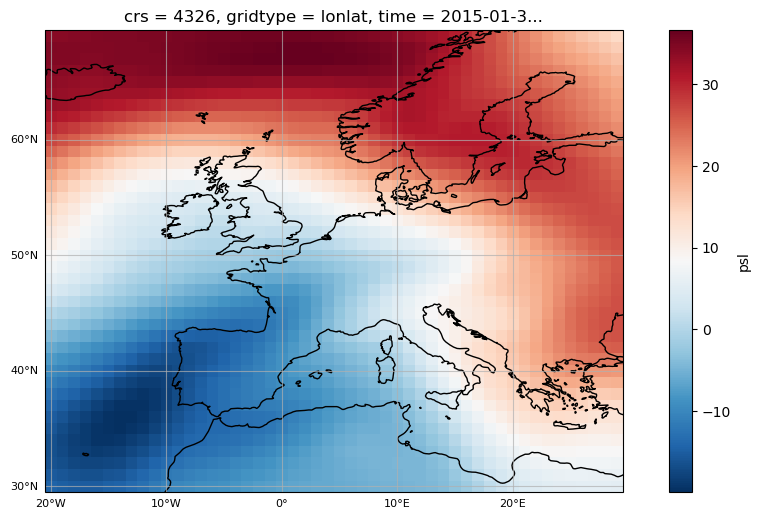

In [9]:


da2 = anom.isel(time=30, ESM_run=0)

# Ensure vmin/vmax are numbers
vmin = float(da2['psl'].where(da2['psl'] > 0).min() / 100)
vmin = float(da2['psl'].min() / 100)

vmax = float(da2['psl'].max() / 100)

# Create figure and map
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Adjust longitudes
new_lon = ((da2['psl'].lon + 180) % 360) - 180
da2 = da2['psl'].assign_coords(lon=new_lon) / 100

# Use pcolormesh explicitly
xr.plot.pcolormesh(da2,
                   ax=ax,
                   transform=ccrs.PlateCarree(),
                   cmap='RdBu_r',
                   vmin=vmin,
                   vmax=vmax,
                   add_colorbar=True)  # optional

# Add coastlines and gridlines
ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

plt.show()

In [8]:
# Check against other data:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/ACCESS-CM2_r4i1p1f1_psl_anomaly.nc'
ds_check = xr.open_dataset(path)
ds_check.load()

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U10 40B 'ACCESS-CM2'
    run       <U8 32B 'r4i1p1f1'
    ESM_run   <U19 76B 'ACCESS-CM2_r4i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 15MB 117.7 153.7 197.0 ... -959.6 -899.2
Attributes:
    regrid_method:  bilinear

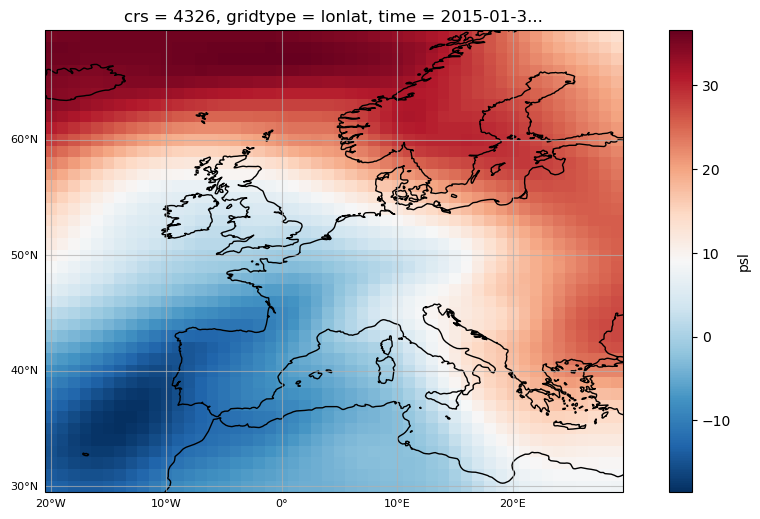

In [10]:

ds_check = ds_check.isel(time=30)

vmin = float(ds_check['psl'].min() / 100)

vmax = float(ds_check['psl'].max() / 100)

# Create figure and map
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Adjust longitudes
new_lon = ((ds_check['psl'].lon + 180) % 360) - 180
ds_check = ds_check['psl'].assign_coords(lon=new_lon) / 100

# Use pcolormesh explicitly
xr.plot.pcolormesh(ds_check,
                   ax=ax,
                   transform=ccrs.PlateCarree(),
                   cmap='RdBu_r',
                   vmin=vmin,
                   vmax=vmax,
                   add_colorbar=True)  # optional

# Add coastlines and gridlines
ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

plt.show()

ValueError: The input coordinate is not sorted in increasing order along axis 0. This can lead to unexpected results. Consider calling the `sortby` method on the input DataArray. To plot data with categorical axes, consider using the `heatmap` function from the `seaborn` statistical plotting library.

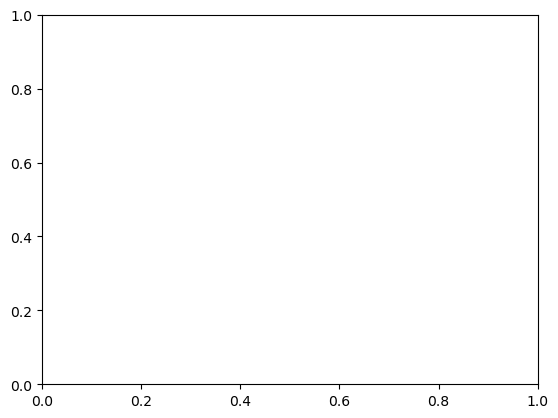

In [81]:
anom['psl'].isel(time = 0, ESM_run = 0).plot()

In [ ]:
clim_pad = xr.concat([clim.isel(dayofyear=slice(-7, None)),
                      clim,
                      clim.isel(dayofyear=slice(0, 7))],
                     dim='dayofyear')
clim_smooth = (
    clim_pad
    .rolling(dayofyear=14, center=True)
    .mean()
    .isel(dayofyear=slice(7, 7+365))
)
clim_smooth


<xarray.Dataset> Size: 3MB
Dimensions:    (lat: 40, lon: 50, dayofyear: 365)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        int64 8B 4326
    gridtype   <U6 24B 'lonlat'
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
    ESM        <U10 40B 'ACCESS-CM2'
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    psl        (dayofyear, lat, lon) float32 3MB 1.023e+05 ... 1.013e+05

In [61]:
ds_mean.time.sel(time=ds_mean.time.dt.dayofyear == 366)

<xarray.DataArray 'time' (time: 3)> Size: 24B
array(['2016-12-31T00:00:00.000000000', '2020-12-31T00:00:00.000000000',
       '2024-12-31T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 24B 2016-12-31 2020-12-31 2024-12-31
    ESM       <U10 40B 'ACCESS-CM2'

In [62]:
clim.load()
# len(clim.dayofyear)

<xarray.Dataset> Size: 3MB
Dimensions:    (dayofyear: 365, lat: 40, lon: 50)
Coordinates:
  * lat        (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs        int64 8B 4326
    gridtype   <U6 24B 'lonlat'
  * lon        (lon) int64 400B 340 341 342 343 344 345 ... 24 25 26 27 28 29
    ESM        <U10 40B 'ACCESS-CM2'
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    psl        (dayofyear, lat, lon) float32 3MB 1.022e+05 ... 1.014e+05

In [58]:
print((ds_mean.time.dt.dayofyear == 2).sum())

print((ds_mean.time.dt.dayofyear == 60).sum())
print((ds_mean.time.dt.dayofyear == 366).sum())

<xarray.DataArray 'dayofyear' ()> Size: 8B
array(10)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U10 40B 'ACCESS-CM2'
<xarray.DataArray 'dayofyear' ()> Size: 8B
array(7)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U10 40B 'ACCESS-CM2'
<xarray.DataArray 'dayofyear' ()> Size: 8B
array(3)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U10 40B 'ACCESS-CM2'


In [50]:
ds_mean.time.dt.dayofyear == 60

<xarray.DataArray 'dayofyear' (time: 3650)> Size: 4kB
array([False, False, False, ..., False, False, False])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U10 40B 'ACCESS-CM2'

In [45]:
clim.isel(dayofyear=61).psl.values

array([[102039.76 , 102038.48 , 102036.08 , ..., 102058.13 , 102050.94 ,
        102042.516],
       [102049.13 , 102051.445, 102052.7  , ..., 102029.   , 102026.   ,
        102022.234],
       [102051.27 , 102058.086, 102064.016, ..., 101996.414, 101994.86 ,
        101992.81 ],
       ...,
       [101148.766, 101116.91 , 101085.12 , ..., 101318.04 , 101327.03 ,
        101335.2  ],
       [101316.805, 101263.72 , 101209.984, ..., 101279.68 , 101295.98 ,
        101311.24 ],
       [101527.04 , 101457.016, 101381.36 , ..., 101224.04 , 101244.11 ,
        101263.1  ]], dtype=float32)

In [ ]:
# Calculate the mean over the ESM dimension and save it to a new file
for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in psl_files if esm in os.path.basename(fn)]
    print(f'Processing {esm} with {len(esm_files)} files...')
    for fn in esm_files:
        print(f'Opening file: {fn}')
        ds = xr.open_dataset(fn)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the mean over the time dimension
        mean_ts_ds = ds.mean(dim='time', keep_attrs=True)
        
        ts_output = mean_ts_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)

    psl_esm_ds = xr.concat(ds_list, dim="ESM_run")

    psl_esm_mean = psl_esm_ds.mean(dim='ESM_run')

    # If there is a run coordinate, remove it
    if 'run' in psl_esm_mean.coords:
        psl_esm_mean = psl_esm_mean.reset_coords('run', drop=True)

    psl_esm_mean = psl_esm_mean.expand_dims(ESM=[esm])
    
    # Save the mean dataset to a new file
    # output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_{esm}.nc')
    output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/winter/psl_mean_{esm}.nc')
    psl_esm_mean.to_netcdf(output_file)
    print(f'Saved mean dataset for {esm} to {output_file}')


In [ ]:

### Old (calculate mean for the whole 6 month time period)
# Calculate the mean over the ESM dimension and save it to a new file
for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in psl_files if esm in os.path.basename(fn)]
    print(f'Processing {esm} with {len(esm_files)} files...')
    for fn in esm_files:
        print(f'Opening file: {fn}')
        ds = xr.open_dataset(fn)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the mean over the time dimension
        mean_ts_ds = ds.mean(dim='time', keep_attrs=True)
        
        ts_output = mean_ts_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)

    psl_esm_ds = xr.concat(ds_list, dim="ESM_run")

    psl_esm_mean = psl_esm_ds.mean(dim='ESM_run')

    # If there is a run coordinate, remove it
    if 'run' in psl_esm_mean.coords:
        psl_esm_mean = psl_esm_mean.reset_coords('run', drop=True)

    psl_esm_mean = psl_esm_mean.expand_dims(ESM=[esm])
    
    # Save the mean dataset to a new file
    # output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_{esm}.nc')
    output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/winter/psl_mean_{esm}.nc')
    psl_esm_mean.to_netcdf(output_file)
    print(f'Saved mean dataset for {esm} to {output_file}')


Processing ACCESS-CM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_psl.nc
Saved mean dataset for ACCESS-CM2 to /climca/people/onennecke/model_output/var_means/psl_not_bc/winter/psl_mean_ACCESS-CM2.nc
Processing BCC-CSM2-MR with 1 files...
Opening file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_psl.nc
Saved mean dataset for BCC-CSM2-MR to /climca/people/onennecke/model_output/var_means/psl_not_bc/winter/psl_mean_BCC-CSM2-MR.nc
Processing CESM2 with 103 files...
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/C

---

In [ ]:
'''path = '/climca/people/onennecke/model_output/var_means/psl_not_bc/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()'''

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.02e+05 1.02e+05 ... 1.012e+05

In [22]:
path = '/climca/people/onennecke/model_output/var_means/psl_not_bc/winter/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.021e+05 1.021e+05 ... 1.011e+05

In [9]:
# Check again with the old files
path = '/climca/people/onennecke/model_output/var_means/psl_not_bc_old/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets_old = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')
# Remove the 'run' coordinate
ts_datasets_old = ts_datasets_old.reset_coords('run', drop=True)
ts_datasets_old.load()
# ts_datasets['psl'].isel(ESM = 0, lat = 0).values

<xarray.Dataset> Size: 186kB
Dimensions:   (lat: 40, lon: 50, ESM: 23)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U13 1kB 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
Data variables:
    psl       (lat, lon, ESM) float32 184kB 1.021e+05 1.022e+05 ... 1.008e+05
Attributes:
    regrid_method:  bilinear

---

In [23]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'

In [24]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM': {'dtype': 'U13'}, 'gridtype': {'dtype': 'U6'}}

In [25]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_combined.nc', encoding=encoding)

In [6]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_combined.nc')
ts_combined.load()

<xarray.Dataset> Size: 97kB
Dimensions:   (ESM: 12, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 96kB 1.021e+05 1.021e+05 ... 1.008e+05

#### Plot

/tmp/ipykernel_2289354/3615381052.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


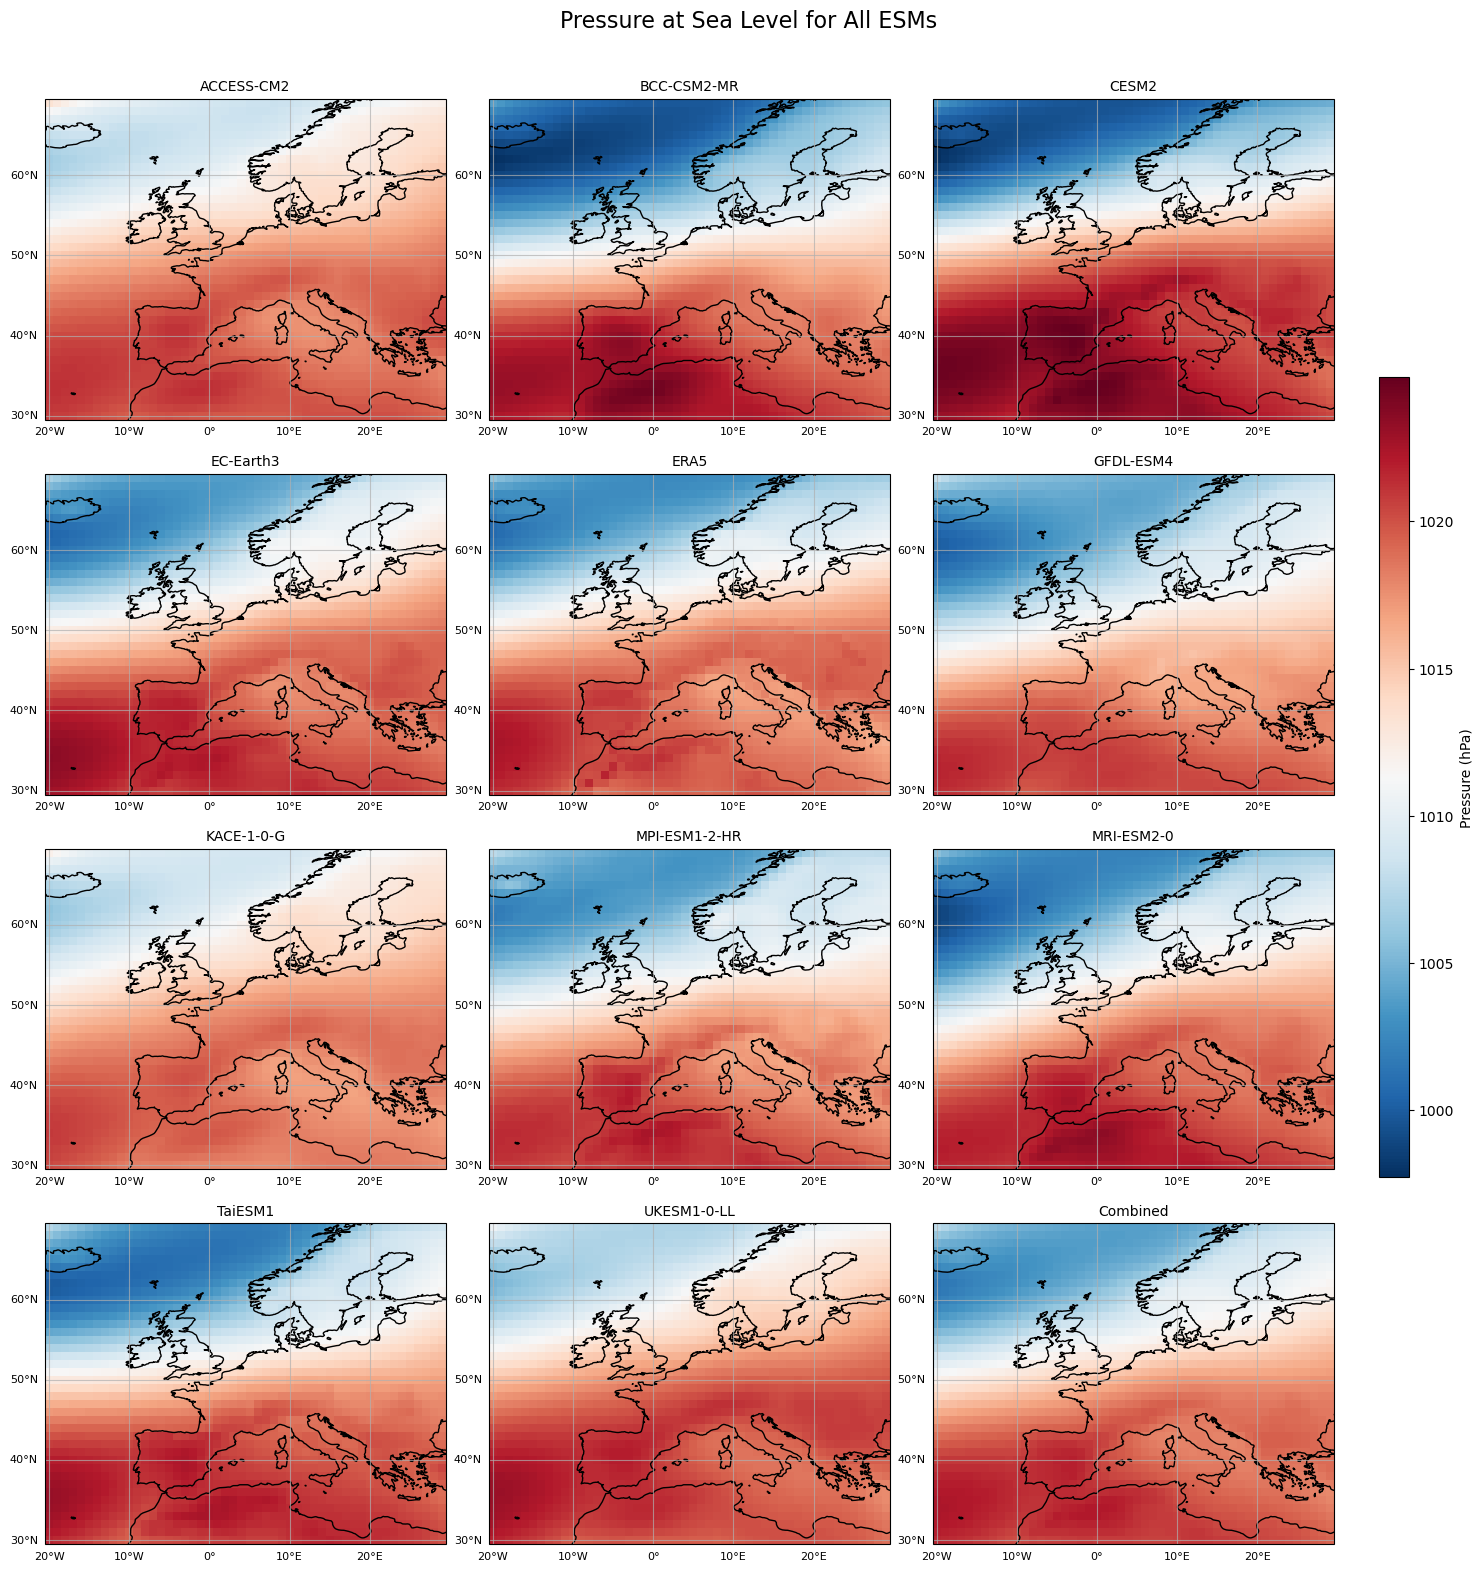

In [27]:
# Define vmin and vmax once
vmin = ts_combined['psl'].where(ts_combined['psl'] > 0).min() / 100
vmax = ts_combined['psl'].max() / 100

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['psl'].lon + 180) % 360) - 180
    da2 = ds['psl'].assign_coords(lon=new_lon) / 100

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

## Calculate Anomaly

In [16]:
xr.open_mfdataset(psl_files[0]).load()

<xarray.Dataset> Size: 29MB
Dimensions:   (time: 3650, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r112i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r112i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 29MB 1.025e+05 1.024e+05 ... 1.004e+05
Attributes:
    regrid_method:  bilinear

In [7]:
counter = 0
for psl_fl in psl_files:
    counter += 1
    run_time = time.time()
    nc = xr.open_mfdataset(psl_fl)
    ESM = nc.ESM.values
    if ESM == 'CESM2_LE':
        ESM = 'CESM2'
    run = nc.run.values
    print(f'{counter} / {len(psl_files)}: Processing {ESM}, {run}')

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    psl_anomaly = nc.copy()
    # Calculate anomaly
    psl_anomaly['psl'] = nc['psl'] - ts_combined.sel(ESM = ESM)['psl']

    ts_output = psl_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/not_bc/{ESM}_{run}_psl_anomaly.nc')
    # break


1 / 193: Processing ACCESS-CM2, r4i1p1f1
2 / 193: Processing ACCESS-CM2, r5i1p1f1
3 / 193: Processing ACCESS-CM2, r1i1p1f1
4 / 193: Processing BCC-CSM2-MR, r1i1p1f1
5 / 193: Processing CESM2, r4i1p1f1
6 / 193: Processing CESM2, r10i1p1f1
7 / 193: Processing CESM2, r11i1p1f1
8 / 193: Processing EC-Earth3, r149i1p1f1
9 / 193: Processing EC-Earth3, r4i1p1f1
10 / 193: Processing EC-Earth3, r148i1p1f1
11 / 193: Processing EC-Earth3, r105i1p1f1
12 / 193: Processing EC-Earth3, r134i1p1f1
13 / 193: Processing EC-Earth3, r141i1p1f1
14 / 193: Processing EC-Earth3, r146i1p1f1
15 / 193: Processing EC-Earth3, r112i1p1f1
16 / 193: Processing EC-Earth3, r117i1p1f1
17 / 193: Processing EC-Earth3, r125i1p1f1
18 / 193: Processing EC-Earth3, r113i1p1f1
19 / 193: Processing EC-Earth3, r106i1p1f1
20 / 193: Processing EC-Earth3, r138i1p1f1
21 / 193: Processing EC-Earth3, r5i1p1f1
22 / 193: Processing EC-Earth3, r137i1p1f1
23 / 193: Processing EC-Earth3, r145i1p1f1
24 / 193: Processing EC-Earth3, r114i1p1f1


In [8]:
ts_output

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    psl       (time, lat, lon) float32 15MB 694.5 718.4 ... -2.051e+03
Attributes:
    regrid_method:  bilinear

### Load data again

In [9]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 3GB
Dimensions:   (ESM_run: 193, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 3GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

/tmp/ipykernel_2293930/3414079843.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


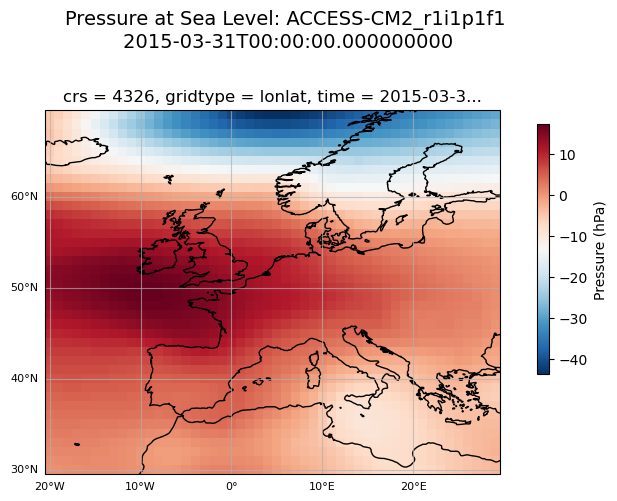

In [10]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='ACCESS-CM2_r1i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].where(tst['psl'] > 0).min() / 100
vmin_da = tst['psl'].min() / 100

vmax_da = tst['psl'].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: ACCESS-CM2_r1i1p1f1\n {tst.time.values}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


## Future data

In [11]:
used_runs_fut = pd.concat([used_runs_CMIP, used_runs_CESM], ignore_index=True)
used_runs_fut


,ESM,Institution,run
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1
3,BCC-CSM2-MR,BCC,r1i1p1f1
4,CESM2,NCAR,r4i1p1f1
...,...,...,...
187,CESM2,NCAR,LE2-1301_016
188,CESM2,NCAR,LE2-1301_017
189,CESM2,NCAR,LE2-1301_018
190,CESM2,NCAR,LE2-1301_019


In [12]:
base_path_fut = '/climca/people/onennecke/not_debiased_data_future/'
psl_files_fut = []
for i in range(len(used_runs_fut)):
    ESM = used_runs_fut.loc[i, 'ESM']
    run = used_runs_fut.loc[i, 'run']
    
    # Construct the file path
    file_path = os.path.join(base_path_fut, f'{ESM}_{run}_psl.nc')
    # Check if the file exists    
    if not os.path.isfile(file_path):
        print(f'File not found: {file_path}')
    else:
        psl_files_fut.append(file_path)
print(len(psl_files_fut))




192


In [13]:
counter = 0
for psl_fl_fut in psl_files_fut:
    counter += 1
    run_time = time.time()
    nc = xr.open_mfdataset(psl_fl_fut)
    ESM = nc.ESM.values
    if ESM == 'CESM2_LE':
        ESM = 'CESM2'
    run = nc.run.values
    print(f'{counter} / {len(psl_files_fut)}: Processing {ESM}, {run}')

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    psl_anomaly = nc.copy()
    # Calculate anomaly
    psl_anomaly['psl'] = nc['psl'] - ts_combined.sel(ESM = ESM)['psl']

    ts_output = psl_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/not_bc_fut/{ESM}_{run}_psl_anomaly.nc')
    # break


1 / 192: Processing ACCESS-CM2, r4i1p1f1
2 / 192: Processing ACCESS-CM2, r5i1p1f1
3 / 192: Processing ACCESS-CM2, r1i1p1f1
4 / 192: Processing BCC-CSM2-MR, r1i1p1f1
5 / 192: Processing CESM2, r4i1p1f1
6 / 192: Processing CESM2, r10i1p1f1
7 / 192: Processing CESM2, r11i1p1f1
8 / 192: Processing EC-Earth3, r149i1p1f1
9 / 192: Processing EC-Earth3, r4i1p1f1
10 / 192: Processing EC-Earth3, r148i1p1f1
11 / 192: Processing EC-Earth3, r105i1p1f1
12 / 192: Processing EC-Earth3, r134i1p1f1
13 / 192: Processing EC-Earth3, r141i1p1f1
14 / 192: Processing EC-Earth3, r146i1p1f1
15 / 192: Processing EC-Earth3, r112i1p1f1
16 / 192: Processing EC-Earth3, r117i1p1f1
17 / 192: Processing EC-Earth3, r125i1p1f1
18 / 192: Processing EC-Earth3, r113i1p1f1
19 / 192: Processing EC-Earth3, r106i1p1f1
20 / 192: Processing EC-Earth3, r138i1p1f1
21 / 192: Processing EC-Earth3, r5i1p1f1
22 / 192: Processing EC-Earth3, r137i1p1f1
23 / 192: Processing EC-Earth3, r145i1p1f1
24 / 192: Processing EC-Earth3, r114i1p1f1
